<h2>Integrality Gap of Vertex Cover</h2>

We will rehash the simple proof that vertex cover problem ILP has an integrality gap of  2  . In other words, the optimal ILP solution is no more than a factor of  2  away from the optimal LP solution.

Recall the definition of integrality gap. Let us consider a an ILP (minimization problem)  𝑃   that yields an optimal solution of  𝑝<sup>∗</sup>  and a corresponding LP relaxation that yields an optimal solution of  𝑙<sup>∗</sup> .

We know that  𝑙∗≤𝑝∗ since this is a minimization problem.
We have shown examples previously that  𝑙∗ can be arbitrarily far away from  𝑝∗

The integrality gap is defined as the ratio between best ILP solution and the best LP relaxation:  𝑝<sup>∗</sup>/𝑙<sup>∗</sup>
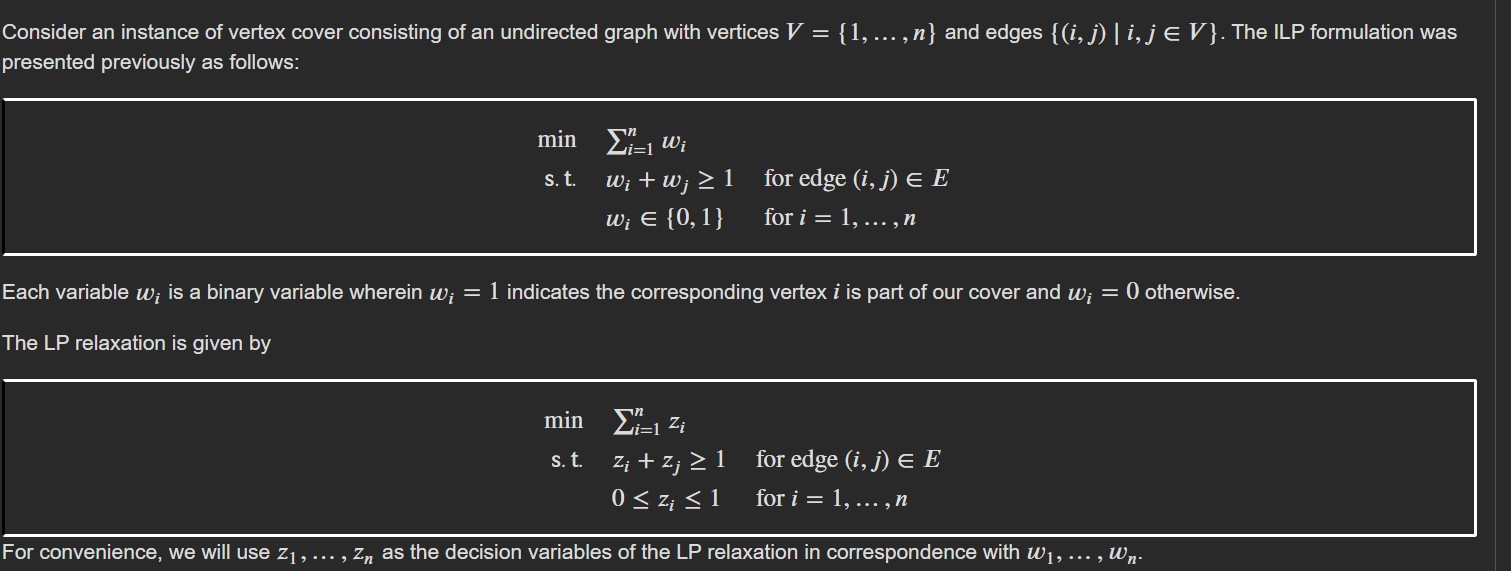

 

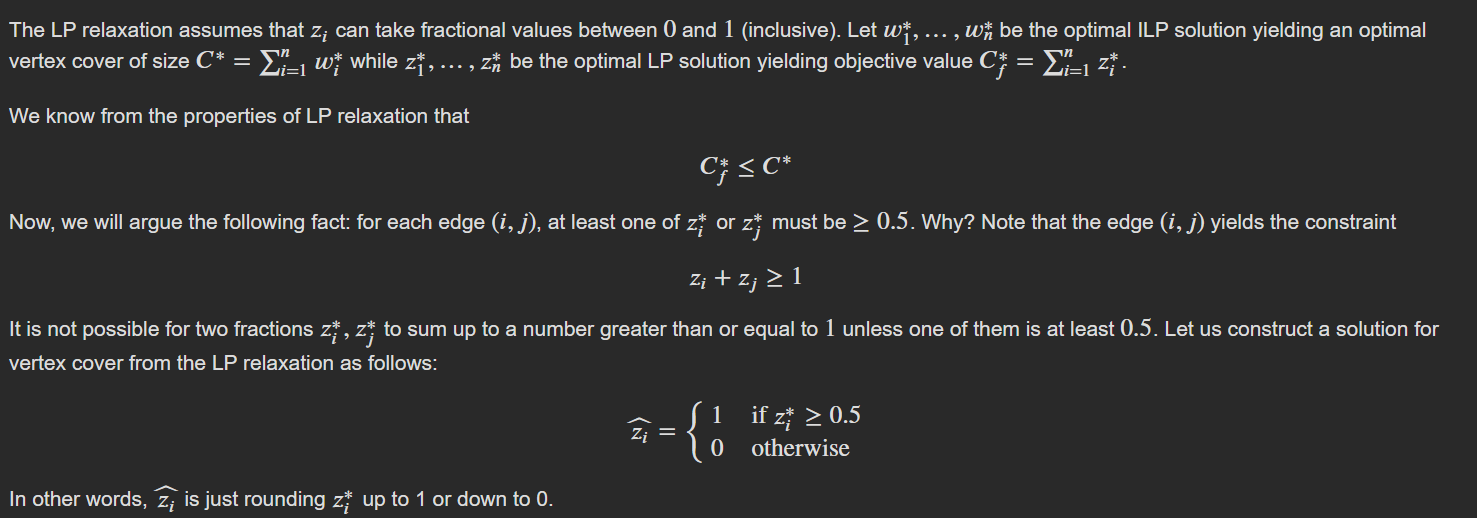
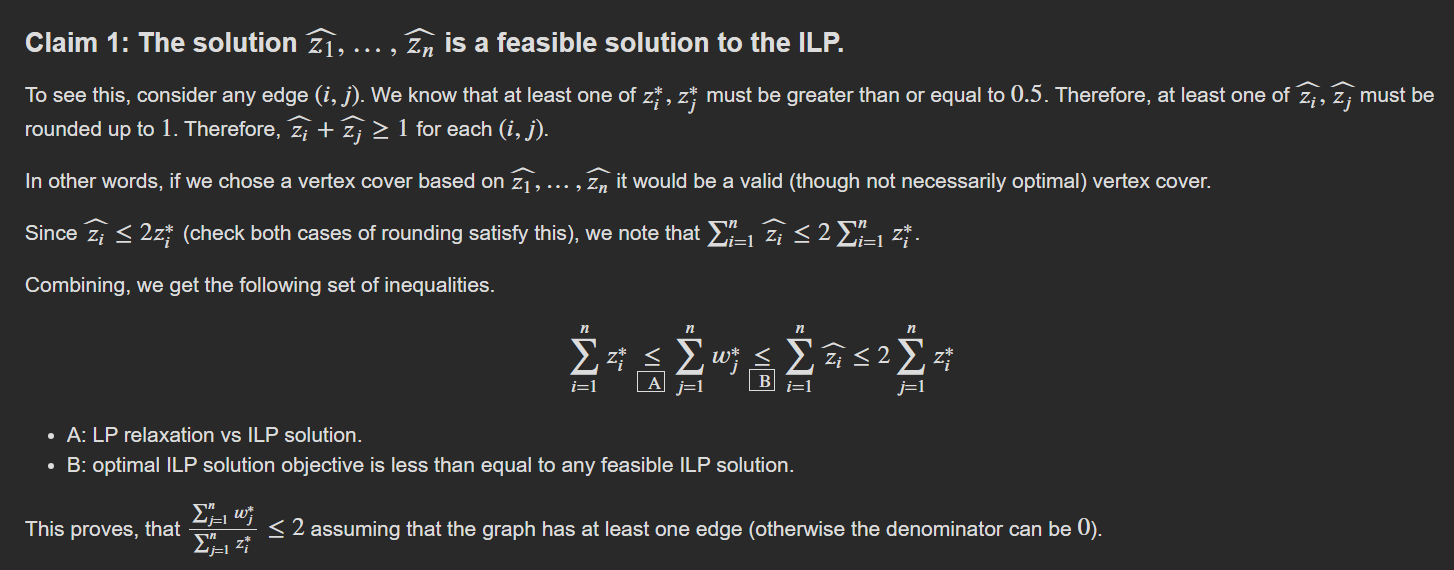
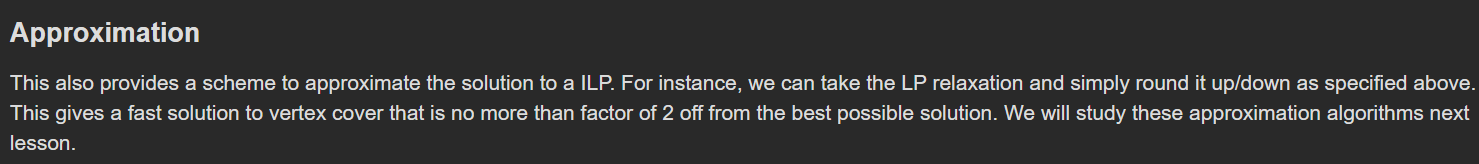

In [49]:
from pulp import *


def compute_optimal_vertex_cover_ilp(n, edge_list): # this is ILP based optimal vertex cover
    # Create a problem -- indicate that we will minimize the objectives
    prob = LpProblem('vert_cover', LpMinimize)
    # Add all the decision vars (we do this using comprehensions in Python but you could write a for-loop as well)
    dvars = [LpVariable(f'w_{i}', cat='Binary') for i in range(1, n+1)]
    # Note that lpSum is defined in Pulp and it simply takes the sum of all variables in a list of vars.
    prob += lpSum(dvars) # minimize the sum of the variables
    for (i, j) in edge_list: # go through each edge in the list
        assert 1 <= i <= n 
        assert 1 <= j <= n
        prob += dvars[i-1] + dvars[j-1] >= 1 # add the constraint -- wi + wj >= 1 -- indexing in python starts from 0 and thus we require the -1
    stat = prob.solve(PULP_CBC_CMD(msg=False)) # solve the problem but suppress output
    assert stat == LpStatusOptimal, 'Problem does not have optimal status -- something went wrong -- this should not happen for this problem'
    vert_cover = [i+1 for i in range(n) if dvars[i].varValue > 0 ]
    return len(vert_cover)


def compute_optimal_vertex_cover_ilp_with_vertices(n, edge_list): # this is ILP based optimal vertex cover
    # Create a problem -- indicate that we will minimize the objectives
    prob = LpProblem('vert_cover', LpMinimize)
    # Add all the decision vars (we do this using comprehensions in Python but you could write a for-loop as well)
    dvars = [LpVariable(f'w_{i}', cat='Binary') for i in range(1, n+1)]
    # Note that lpSum is defined in Pulp and it simply takes the sum of all variables in a list of vars.
    prob += lpSum(dvars) # minimize the sum of the variables
    for (i, j) in edge_list: # go through each edge in the list
        assert 1 <= i <= n 
        assert 1 <= j <= n
        prob += dvars[i-1] + dvars[j-1] >= 1 # add the constraint -- wi + wj >= 1 -- indexing in python starts from 0 and thus we require the -1
    stat = prob.solve(PULP_CBC_CMD(msg=False)) # solve the problem but suppress output
    assert stat == LpStatusOptimal, 'Problem does not have optimal status -- something went wrong -- this should not happen for this problem'
    vert_cover = [i+1 for i in range(n) if dvars[i].varValue > 0 ]
    vert_cover_vertices = [f'{x}' for x in dvars if x.varValue > 0] 
    return (len(vert_cover),vert_cover_vertices)

In [50]:
edge_list_quiz = []
edge_list_quiz.append((1,2))
edge_list_quiz.append((1,3))
edge_list_quiz.append((1,4))
edge_list_quiz.append((2,3))
edge_list_quiz.append((2,6))
edge_list_quiz.append((3,4))
edge_list_quiz.append((3,5))
edge_list_quiz.append((3,6))
edge_list_quiz.append((4,5))
edge_list_quiz.append((4,7))
edge_list_quiz.append((5,7))
edge_list_quiz.append((6,5))
edge_list_quiz.append((6,7))
opt_ilp = compute_optimal_vertex_cover_ilp(7, edge_list_quiz)
print(f'opt_ilp={opt_ilp}')
(opt_ilp_value,opt_ilp_vertices) = compute_optimal_vertex_cover_ilp_with_vertices(7, edge_list_quiz)
print(f'opt_ilp_value={opt_ilp_value},opt_ilp_vertices={opt_ilp_vertices}')








opt_ilp=5
opt_ilp_value=5,opt_ilp_vertices=['w_2', 'w_3', 'w_4', 'w_6', 'w_7']


In [53]:
def compute_lp_relaxation_vertex_cover(n, edge_list):
    # Create a problem -- indicate that we will minimize the objectives
    prob = LpProblem('vert_cover', LpMinimize)
    # Add all the decision vars (we do this using comprehensions in Python but you could write a for-loop as well)
    dvars = [LpVariable(f'z_{i}', lowBound=0.0, upBound=1.0, cat='Continuous') for i in range(1, n+1)]
    # Note that lpSum is defined in Pulp and it simply takes the sum of all variables in a list of vars.
    prob += lpSum(dvars) # minimize the sum of the variables
    for (i, j) in edge_list: # go through each edge in the list
        assert 1 <= i <= n 
        assert 1 <= j <= n
        prob += dvars[i-1] + dvars[j-1] >= 1 # add the constraint -- wi + wj >= 1 -- indexing in python starts from 0 and thus we require the -1
    stat = prob.solve(PULP_CBC_CMD(msg=False)) # solve the problem but suppress the output
    assert stat == LpStatusOptimal, 'Problem does not have optimal status -- something went wrong -- this should not happen for this problem'
    vert_cover = [x.varValue for x in dvars]
    return sum(vert_cover)

def compute_lp_relaxation_vertex_cover_vertices(n, edge_list):
    # Create a problem -- indicate that we will minimize the objectives
    prob = LpProblem('vert_cover', LpMinimize)
    # Add all the decision vars (we do this using comprehensions in Python but you could write a for-loop as well)
    dvars = [LpVariable(f'z_{i}', lowBound=0.0, upBound=1.0, cat='Continuous') for i in range(1, n+1)]
    # Note that lpSum is defined in Pulp and it simply takes the sum of all variables in a list of vars.
    prob += lpSum(dvars) # minimize the sum of the variables
    for (i, j) in edge_list: # go through each edge in the list
        assert 1 <= i <= n 
        assert 1 <= j <= n
        prob += dvars[i-1] + dvars[j-1] >= 1 # add the constraint -- wi + wj >= 1 -- indexing in python starts from 0 and thus we require the -1
    stat = prob.solve(PULP_CBC_CMD(msg=False)) # solve the problem but suppress the output
    assert stat == LpStatusOptimal, 'Problem does not have optimal status -- something went wrong -- this should not happen for this problem'
    vert_cover = [x.varValue for x in dvars] 
    vert_cover_vertices = [f'{x},{x.varValue}' for x in dvars if x.varValue>=0.5]
    return (sum(vert_cover),vert_cover_vertices)

def compute_lp_relaxation_with_rounding_vertex_cover(n, edge_list):
    # Create a problem -- indicate that we will minimize the objectives
    prob = LpProblem('vert_cover', LpMinimize)
    # Add all the decision vars (we do this using comprehensions in Python but you could write a for-loop as well)
    dvars = [LpVariable(f'z_{i}', lowBound=0.0, upBound=1.0, cat='Continuous') for i in range(1, n+1)]
    # Note that lpSum is defined in Pulp and it simply takes the sum of all variables in a list of vars.
    prob += lpSum(dvars) # minimize the sum of the variables
    for (i, j) in edge_list: # go through each edge in the list
        assert 1 <= i <= n 
        assert 1 <= j <= n
        prob += dvars[i-1] + dvars[j-1] >= 1 # add the constraint -- wi + wj >= 1 -- indexing in python starts from 0 and thus we require the -1
    stat = prob.solve(PULP_CBC_CMD(msg=False)) # solve the problem but suppress the output
    assert stat == LpStatusOptimal, 'Problem does not have optimal status -- something went wrong -- this should not happen for this problem'
    vert_cover = [1 if x.varValue>=0.5 else 0  for x in dvars] # this is solution with rounding
    vert_cover_vertices = [f'{x},{x.varValue}' for x in dvars if x.varValue>=0.5]
    return (sum(vert_cover),vert_cover_vertices)

In [54]:
edge_list_quiz_lp = []
edge_list_quiz_lp.append((1,2))
edge_list_quiz_lp.append((1,3))
edge_list_quiz_lp.append((1,4))
edge_list_quiz_lp.append((2,3))
edge_list_quiz_lp.append((2,6))
edge_list_quiz_lp.append((3,4))
edge_list_quiz_lp.append((3,5))
edge_list_quiz_lp.append((3,6))
edge_list_quiz_lp.append((4,5))
edge_list_quiz_lp.append((4,7))
edge_list_quiz_lp.append((5,7))
edge_list_quiz_lp.append((6,5))
edge_list_quiz_lp.append((6,7))
(opt_lp,opt_lp_vertices) = compute_lp_relaxation_vertex_cover_vertices(7, edge_list_quiz_lp)
print(f'opt lp={opt_lp},opt_lp_vertices={opt_lp_vertices}')
(opt_lp_rounding, lp_rounding_vertices) = compute_lp_relaxation_with_rounding_vertex_cover(7, edge_list_quiz_lp)
print(f'opt_lp_rounding={opt_lp_rounding}, lp_rounding_vertices={lp_rounding_vertices}')








opt lp=3.5,opt_lp_vertices=['z_1,0.5', 'z_2,0.5', 'z_3,0.5', 'z_4,0.5', 'z_5,0.5', 'z_6,0.5', 'z_7,0.5']
opt_lp_rounding=7, lp_rounding_vertices=['z_1,0.5', 'z_2,0.5', 'z_3,0.5', 'z_4,0.5', 'z_5,0.5', 'z_6,0.5', 'z_7,0.5']


In [55]:
## generate a random graph with n nodes and m edges + compute both optimal cover using ILP and LP relaxations
from random import randint
def formulate_random_problem(n, m):
    # n vertices and m edges
    edge_list = []
    for i in range(m):
        done = False
        vi= 1
        vj = n
        while not done: # get two random vertices
            vi, vj = randint(1, n), randint(1, n)
            vi, vj = min(vi, vj), max(vi, vj)
            if vi != vj and (vi, vj) not in edge_list: # if they are not the same vertex or we have not seen the edge previously
                done = True
        edge_list.append((vi, vj))
    assert len(edge_list) == m
    n1 = compute_optimal_vertex_cover_ilp(n, edge_list)
    n2 = compute_lp_relaxation_vertex_cover(n, edge_list)
    return (n1, n2)


In [56]:
# run 50 different random problems
# Each problem generates a random graph with 50 vertices and 240 edges
# This is going to take quite some time
opt_vertex_cover = []
lp_relax_obj = []
print('Opt Cover, Lp Relaxation')
print('------------------------')
for i in range(250):
    n = randint(15, 60)
    m = randint(n*2, n*5)
    print(f'n = {n}, m={m}')
    (n1, n2) = formulate_random_problem(n, m) 
    opt_vertex_cover.append(n1)
    lp_relax_obj.append(n2)
    print(f'opt-cover={n1}, lp-relax={n2}')

Opt Cover, Lp Relaxation
------------------------
n = 28, m=122
opt-cover=19, lp-relax=14.0
n = 60, m=144
opt-cover=34, lp-relax=29.5
n = 20, m=41
opt-cover=11, lp-relax=9.5
n = 44, m=128
opt-cover=26, lp-relax=22.0
n = 53, m=255
opt-cover=36, lp-relax=26.5
n = 41, m=135
opt-cover=25, lp-relax=20.5
n = 56, m=113
opt-cover=30, lp-relax=26.5
n = 56, m=156
opt-cover=34, lp-relax=28.0
n = 37, m=113
opt-cover=21, lp-relax=18.5
n = 56, m=234
opt-cover=38, lp-relax=28.0
n = 45, m=168
opt-cover=29, lp-relax=22.5
n = 27, m=76
opt-cover=16, lp-relax=13.5
n = 33, m=69
opt-cover=18, lp-relax=16.5
n = 38, m=99
opt-cover=23, lp-relax=19.0
n = 55, m=268
opt-cover=40, lp-relax=27.5
n = 45, m=214
opt-cover=32, lp-relax=22.5
n = 47, m=122
opt-cover=27, lp-relax=23.5
n = 38, m=152
opt-cover=24, lp-relax=19.0
n = 52, m=158
opt-cover=31, lp-relax=26.0
n = 21, m=58
opt-cover=13, lp-relax=10.5
n = 42, m=171
opt-cover=28, lp-relax=20.5
n = 17, m=67
opt-cover=12, lp-relax=8.5
n = 22, m=71
opt-cover=14, lp-rela

Text(0, 0.5, 'Optimal Cover')

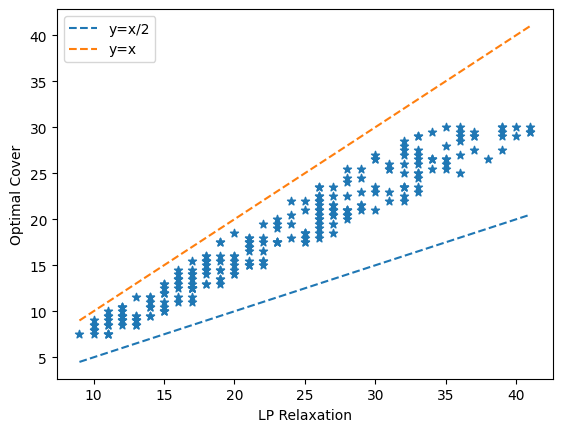

In [5]:
from matplotlib import pyplot as plt
import numpy as np
plt.scatter(opt_vertex_cover, lp_relax_obj,marker='*')
x = np.linspace(min(opt_vertex_cover), max(opt_vertex_cover), 50)
y = x/2
plt.plot(x,y, '--', label='y=x/2')
plt.plot(x,x, '--', label='y=x')
plt.legend()
plt.xlabel('LP Relaxation')
plt.ylabel('Optimal Cover')


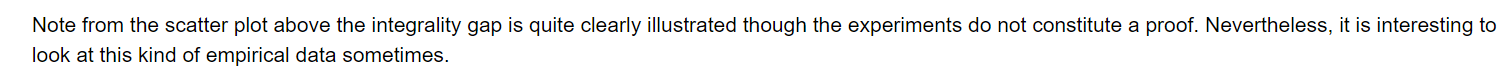
<h3><b>ABove results few of them show lp-relax solution to be evben lesser value than optimal solution - how is that possible ?</b></h3>